In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
DEVICE = torch.device( "cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


In [3]:
df_test = pd.read_csv(r"C:\Users\SAKTHI\Desktop\rework\data\fashion-mnist_test.csv")

print("Test dataset shape:", df_test.shape)

Test dataset shape: (10000, 785)


In [4]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

In [5]:
X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

print("Test images :", X_test.shape)
print("Test labels :", y_test.shape)

Test images : (10000, 784)
Test labels : (10000,)


In [6]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class FashionDataset(Dataset):

    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx]

        # 784 pixels -> 28x28 image
        image = image.reshape(28, 28).astype(np.uint8)

        # Fashion-MNIST grayscale -> RGB
        image = np.stack([image] * 3, axis=-1)

        image = Image.fromarray(image)

        image = self.transform(image)

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return image, label

In [8]:
test_dataset = FashionDataset(X_test,y_test,image_transform)

test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False,num_workers=0,pin_memory=True)

print("Number of test images:", len(test_dataset))

Number of test images: 10000


In [11]:
vgg_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

for param in vgg_model.parameters():
    param.requires_grad = False

vgg_model.classifier = nn.Sequential(

    nn.Linear(25088, 512),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 10)
)


vgg_path = r"C:\Users\SAKTHI\Desktop\rework\models\vgg16_best.pth"

vgg_model.classifier.load_state_dict(torch.load(vgg_path,map_location=DEVICE,weights_only=True))

vgg_model = vgg_model.to(DEVICE)

vgg_model.eval()

print("VGG16 loaded successfully")

VGG16 loaded successfully


In [12]:
resnet_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Sequential(
    
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    
    nn.Linear(256, 10)
)

resnet_path = r"C:\Users\SAKTHI\Desktop\rework\models\resnet50_best.pth"


resnet_model.fc.load_state_dict(torch.load(resnet_path,map_location=DEVICE,weights_only=True ))
resnet_model = resnet_model.to(DEVICE)
resnet_model.eval()

print("ResNet50 loaded successfully")

ResNet50 loaded successfully


In [13]:
efficient_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

for param in efficient_model.features.parameters(): 
    param.requires_grad = False

efficient_model.classifier = nn.Sequential(
    nn.Linear(1280, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.1),
    
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(),
    
    nn.Linear(256, 10)
)

efficient_path = r"C:\Users\SAKTHI\Desktop\rework\models\efficient_best.pth"


efficient_model.classifier.load_state_dict(torch.load(efficient_path,map_location=DEVICE,weights_only=True))

efficient_model = efficient_model.to(DEVICE)
efficient_model.eval()

print("EfficientNet-B0 loaded successfully")

EfficientNet-B0 loaded successfully


In [14]:
def evaluate_model(model, loader):
    
    model.eval()
    
    actual_labels = []
    
    predicted_labels = []
    
    total_inference_time = 0
    
    
    with torch.no_grad():
        
        for images, labels in loader:
            
            images = images.to(DEVICE)

            # Synchronize GPU before measuring time
            if DEVICE.type == "cuda":
                torch.cuda.synchronize()
            
            start_time = time.perf_counter()

            # Model prediction
            outputs = model(images)

            if DEVICE.type == "cuda":
                torch.cuda.synchronize()

            end_time = time.perf_counter()

            total_inference_time += ( end_time - start_time)     
                   
            # Select class with highest score 
            predictions = torch.argmax( outputs, dim=1 ) 
            actual_labels.extend( labels.numpy() ) 
            predicted_labels.extend( predictions.cpu().numpy() )
    
    
    # Accuracy
    
    accuracy = accuracy_score(actual_labels,predicted_labels)
    # Precision
    precision = precision_score(actual_labels,predicted_labels,average="weighted",zero_division=0) 
    # Recall
    recall = recall_score(actual_labels, predicted_labels, average="weighted", zero_division=0)
    # F1 score
    f1 = f1_score( actual_labels, predicted_labels, average="weighted", zero_division=0)
    # Average inference time per image
    inference_time = ( total_inference_time / len(actual_labels)) * 1000
 
    return ( accuracy,precision, recall, f1, inference_time, actual_labels, predicted_labels)

In [15]:
models_dict = {
    "VGG16": vgg_model,
    "ResNet50": resnet_model,
    "EfficientNetB0": efficient_model
}

results = []

predictions_dict = {}


for model_name, model in models_dict.items():
    
    print(f"\nEvaluating {model_name}...")
    
    accuracy, precision, recall, f1, inference_time, actual, predicted = evaluate_model(
        model,
        test_loader
    )
    
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Inference Time (ms/image)": inference_time
    })
    
    
    predictions_dict[model_name] = {
        "actual": actual,
        "predicted": predicted
    }
    
    
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"Inference Time : {inference_time:.4f} ms/image")


Evaluating VGG16...
Accuracy       : 0.9380
Precision      : 0.9379
Recall         : 0.9380
F1 Score       : 0.9378
Inference Time : 7.9577 ms/image

Evaluating ResNet50...
Accuracy       : 0.9129
Precision      : 0.9136
Recall         : 0.9129
F1 Score       : 0.9125
Inference Time : 3.7938 ms/image

Evaluating EfficientNetB0...
Accuracy       : 0.9257
Precision      : 0.9251
Recall         : 0.9257
F1 Score       : 0.9249
Inference Time : 1.6327 ms/image


In [16]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Inference Time (ms/image)
0,VGG16,0.9380,0.937881,0.9380,0.937830,7.957723
1,ResNet50,0.9129,0.913583,0.9129,0.912480,3.793755
2,EfficientNetB0,0.9257,0.925103,0.9257,0.924865,1.632750


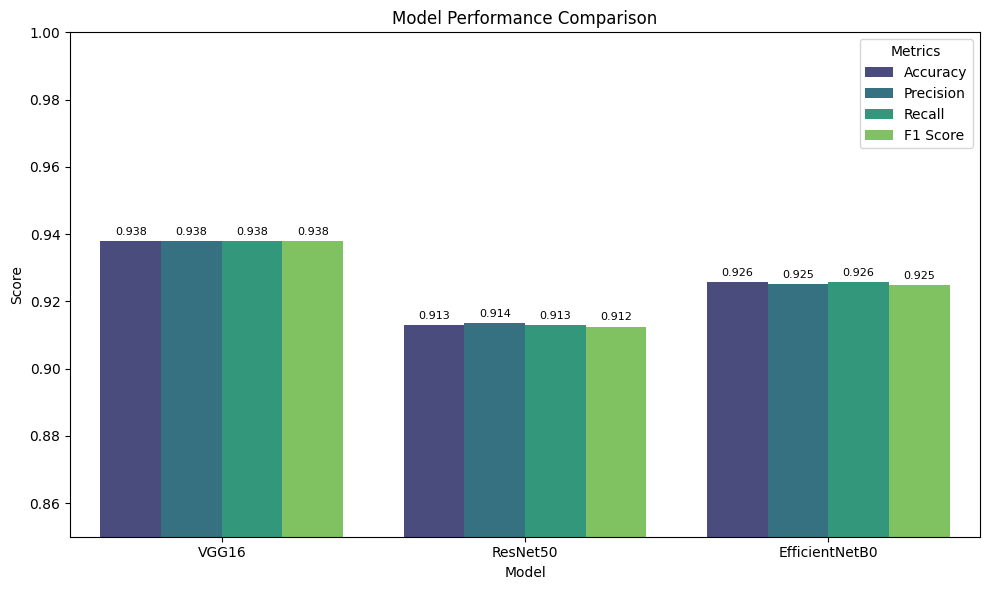

In [29]:
import seaborn as sns

metrics_df = results_df.melt(id_vars="Model",value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],var_name="Metric",value_name="Score")

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=metrics_df,x="Model",y="Score",hue="Metric",palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)


plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)

plt.legend(title="Metrics")
plt.tight_layout()
plt.show()


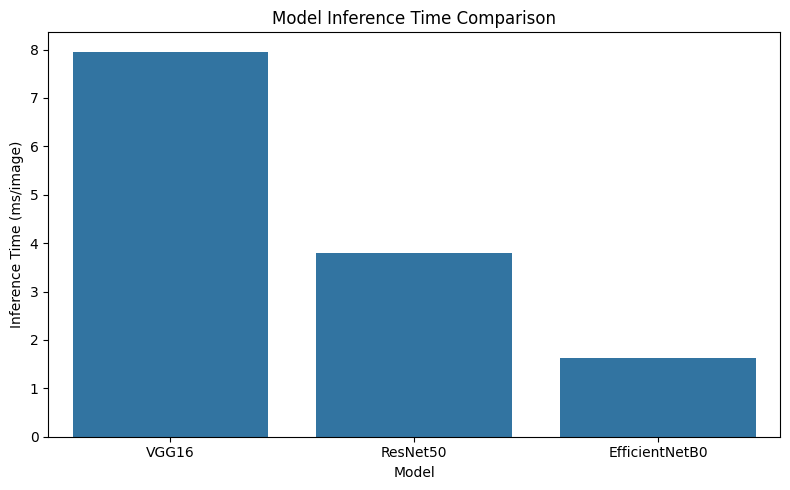

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(data=results_df,x="Model",y="Inference Time (ms/image)")

plt.title("Model Inference Time Comparison")
plt.xlabel("Model")
plt.ylabel("Inference Time (ms/image)")

plt.tight_layout()
plt.show()